In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260604-40008-qcodes.log
Experiment loaded. Last ID no: 116


In [217]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

In [3]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

2026-06-04 09:22:07,542 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\PPCL550.py:4: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import create_on_off_val_mapping



Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.80s
Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.03s
Connected to: PurePhotonic PPCL550 (serial:PP70AJ005, firmware:PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0) in 1.60s


2026-06-04 09:22:10,217 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\MSO5.py:5: QCoDeSDeprecationWarning: The `qcodes.instrument.base` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.instrument.base import InstrumentBase



Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.60s


2026-06-04 09:22:16,154 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-06-04 09:22:16,294 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.14s


In [10]:
device = params.device_line_2

In [174]:
params.initialize_station()

In [6]:
params.initialize_station()
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
device = params.device_line_2
# Positive sweep (currents are stored as negative)
currents = [-i for i in device['currents']]
params.critical_current(currents=currents, device_name=device['name'])

Ramping to 0
update station
Starting experimental run with id: 117. 
117
Starting current -0.0
Starting current 2.5e-07
Starting current 5e-07
Starting current 7.5e-07
Starting current 1e-06
Starting current 1.25e-06
Starting current 1.5e-06
Starting current 1.75e-06
Starting current 2e-06
Starting current 2.25e-06
Starting current 2.5e-06
Starting current 2.75e-06
Starting current 3e-06
Starting current 3.25e-06
Starting current 3.5e-06
Starting current 3.75e-06
Starting current 4e-06
Starting current 4.25e-06
Starting current 4.5e-06
Starting current 4.75e-06
Starting current 5e-06
Starting current 5.25e-06
Starting current 5.5e-06
Starting current 5.75e-06
Starting current 6e-06
Starting current 6.25e-06
Starting current 6.5e-06
Starting current 6.75e-06
Starting current 7e-06
Starting current 7.25e-06
Starting current 7.5e-06
Starting current 7.75e-06
Starting current 8e-06
Starting current 8.25e-06
Starting current 8.5e-06
Starting current 8.75e-06
Starting current 9e-06
Starting 

In [7]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0


In [8]:
params.initialize_station()
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
device = params.device_line_2
# Negative sweep 
currents = device['currents']
params.critical_current(currents=currents, device_name=device['name'])

Ramping to 0
update station
Starting experimental run with id: 118. 
118
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-0

In [9]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0


In [11]:
params.ramp_yoko_current(yoko=yoko, target=9e-6, step=0.5e-6)
yoko.current(9e-6)

Ramping to 9e-06


In [12]:
params.capture_trace(MS, dmm, yoko, p_att=p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 119. 
119
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.440E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #119, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

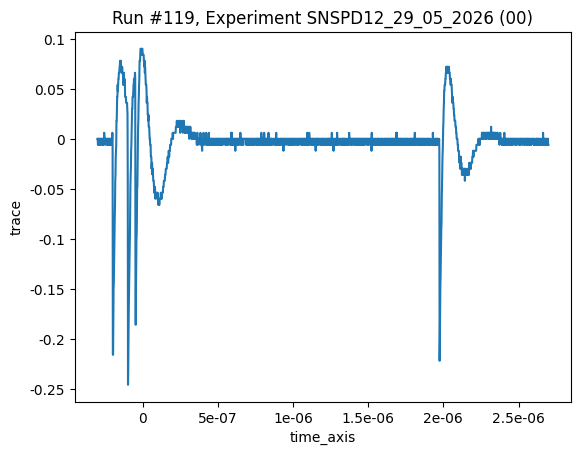

In [13]:
plot_by_id(119)

Positive voltage creates negative peaks which is strange. 

In [14]:
params.ramp_yoko_current(yoko=yoko, target=-9e-6, step=0.5e-6)
yoko.current(-9e-6)

Ramping to -9e-06


In [16]:
params.capture_trace(MS, dmm, yoko, p_att=p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 120. 
120
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.250E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #120, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

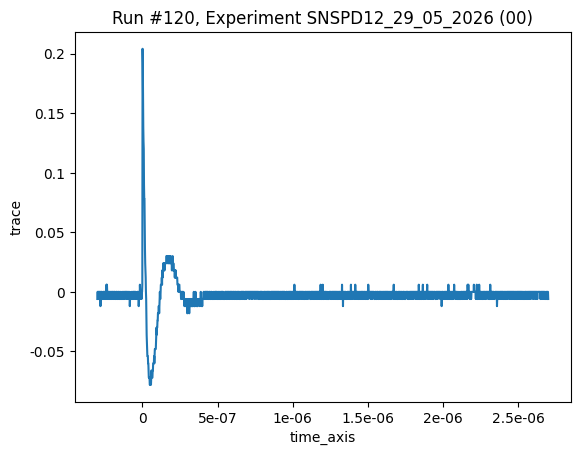

In [17]:
plot_by_id(120)

In [19]:
# The laser was enabled during this run! 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(5)


for i in params.device_line_2['currents']: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att)


params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 121. 
121
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 122. 
122
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 123. 
123
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 124. 
124
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC

Run dummy system dark counts to see when the thing transitions. Looks like it is counting well above the current transition. 

In [20]:
# The laser was enabled during this run!! This is actually light counts. 
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)


params.MSO5_counts_vs_current(device=params.device_line_2, n_captures=10, interval=1)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 174. 
174
0.05
This acquisition will take 10s
11 18


2026-06-04 11:18:49,701 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



0.05
This acquisition will take 10s
11 19


2026-06-04 11:19:11,878 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



0.05
This acquisition will take 10s
11 19


...

0.1
This acquisition will take 10s
11 37


2026-06-04 11:37:40,436 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



0.1
This acquisition will take 10s
11 37


2026-06-04 11:38:02,597 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Ramping to 0


In [23]:
laser.enable(False)

In [24]:
laser.enable()

False

Try current sweeps again in case results were affected 

In [25]:
params.initialize_station()
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
device = params.device_line_2
# Positive sweep (currents are stored as negative)
currents = [-i for i in device['currents']]
params.critical_current(currents=currents, device_name=device['name'])


params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

# Negative sweep 
currents = device['currents']
params.critical_current(currents=currents, device_name=device['name'])

Ramping to 0
update station
Starting experimental run with id: 175. 
175
Starting current -0.0
Starting current 2.5e-07
Starting current 5e-07
Starting current 7.5e-07
Starting current 1e-06
Starting current 1.25e-06
Starting current 1.5e-06
Starting current 1.75e-06
Starting current 2e-06
Starting current 2.25e-06
Starting current 2.5e-06
Starting current 2.75e-06
Starting current 3e-06
Starting current 3.25e-06
Starting current 3.5e-06
Starting current 3.75e-06
Starting current 4e-06
Starting current 4.25e-06
Starting current 4.5e-06
Starting current 4.75e-06
Starting current 5e-06
Starting current 5.25e-06
Starting current 5.5e-06
Starting current 5.75e-06
Starting current 6e-06
Starting current 6.25e-06
Starting current 6.5e-06
Starting current 6.75e-06
Starting current 7e-06
Starting current 7.25e-06
Starting current 7.5e-06
Starting current 7.75e-06
Starting current 8e-06
Starting current 8.25e-06
Starting current 8.5e-06
Starting current 8.75e-06
Starting current 9e-06
Starting 

Re-do trace capture with laser off. 

In [26]:
laser.enable()

False

In [27]:
yoko.current()

-1.3e-05

In [28]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

for i in params.device_line_2['currents']: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att)


params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 177. 
177
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 178. 
178
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 179. 
179
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 180. 
180
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC

Current -8.25uA caught no trace. Add trace in. 

In [30]:
params.ramp_yoko_current(yoko=yoko, target=-8.25e-6, step = 0.5e-6)
yoko.current(-8.25e-6)
time.sleep(120)

params.capture_trace(MS, dmm, yoko, p_att=p_att)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to -8.25e-06
Oscilloscope set for trace capture
update station
Starting experimental run with id: 230. 
230
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;685.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Ramping to 0


In [ ]:
plot_by_id(230)

In [31]:
# Run through trigger values - see what the smallest interval on the trigger is 
triggers = np.arange(0, 25e-3, 5e-3) 
for trigger in triggers: 
    print(f'Expecting {trigger}')
    MS.trigger_channels[0].ch1_trigger_level(trigger)
    time.sleep(20)
    print(MS.trigger_channels[0].ch1_trigger_level())

Expecting 0.0
0.0
Expecting 0.005
0.006
Expecting 0.01
0.012
Expecting 0.015
0.012
Expecting 0.02
0.018


In [32]:
trigger = 100e-3
MS.trigger_channels[0].ch1_trigger_level(trigger)
time.sleep(20)
print(MS.trigger_channels[0].ch1_trigger_level())

0.102


The channel 1 trigger seems only settable as multiples of 0.006.Try lower than 0.006.  

In [46]:
# Run through trigger values - see what the smallest interval on the trigger is 
mult = np.arange(0, 18) 
for mult in mult: 
    trigger = 0.006*mult
    print(f'Expecting {trigger:.3f}')
    MS.trigger_channels[0].ch1_trigger_level(trigger)
    time.sleep(2)
    print(MS.trigger_channels[0].ch1_trigger_level())

Expecting 0.000
0.0
Expecting 0.006
0.006
Expecting 0.012
0.012
Expecting 0.018
0.018
Expecting 0.024
0.024
Expecting 0.030
0.03
Expecting 0.036
0.036
Expecting 0.042
0.042
Expecting 0.048
0.048
Expecting 0.054
0.054
Expecting 0.060
0.06
Expecting 0.066
0.066
Expecting 0.072
0.072
Expecting 0.078
0.078
Expecting 0.084
0.084
Expecting 0.090
0.09
Expecting 0.096
0.096
Expecting 0.102
0.102


Running trace sweep for lowest possible trigger based on ringing

In [1]:
8*0.006

0.048

In [52]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

min_trig = 8*0.006 # 48mV 

for i in params.device_line_2['currents'][:21]: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 231. 
231
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 232. 
232
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 233. 
233
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 234. 
234
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC

Many triggers didn't get anything - need to make capture trace based on single trigger. 0 means the acquisition has stopped and a trigger event has happened. 

In [128]:
MS.write('ACQUIRE:STOPAFTER RUNSTOP')
MS.write('ACQUIRE:STATE ON')

In [133]:
MS.ask('ACQUIRE:STOPAFTER?')

'RUNSTOP'

In [135]:
params.initialize_station()

In [136]:
params.ramp_yoko_current(yoko=yoko, target=-5e-6, step = 0.5e-6)
yoko.current(-5e-6)
time.sleep(2)

min_trig = 8*0.006

# yoko.current(i)
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

Ramping to -5e-06
Oscilloscope set for trace capture
update station
Starting experimental run with id: 260. 
260
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.2250E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #260, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

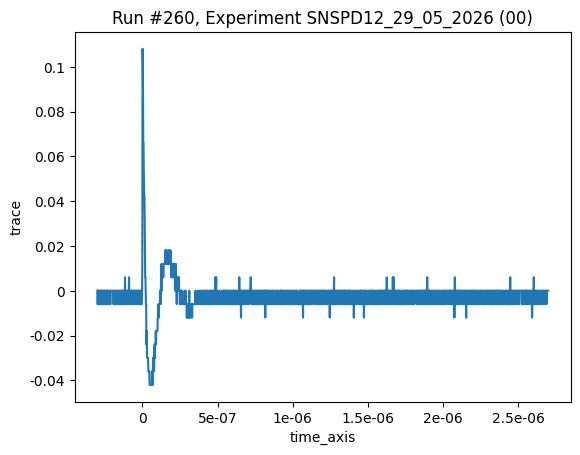

In [137]:
plot_by_id(260)

Re-run low values and get single triggers. From ID 241 and 242, the first to hit the threshold of 48mV was current -2.75uA. Speed up acquisition by going only from this value. Note that -3uA and -3.75uA had no trace and needed single trigger.  

In [141]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

min_trig = 8*0.006

for i in params.device_line_2['currents'][10:21]: # from -2.5uA to -5uA: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)


Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 261. 
261
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;715.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 262. 
262
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.120E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 263. 
263
Acquisition took 2.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.440E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update sta

Peak from ID 261 and current -2.5uA luckily randomly caught a peak! A trigger near 0.01 will clear the overshoot. 0.006*2 = 0.012 

In [146]:
params.device_line_2['currents'][:11]

[0.0,
 -2.5e-07,
 -5e-07,
 -7.5e-07,
 -1e-06,
 -1.25e-06,
 -1.5e-06,
 -1.75e-06,
 -2e-06,
 -2.25e-06,
 -2.5e-06]

In [144]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

min_trig = 2*0.006

for i in params.device_line_2['currents'][:11]: # from 0 to -2.5uA: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 272. 
272
Acquisition took 100.09 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;795.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 273. 
273
Acquisition took 74.07 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;555.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 274. 
274
Acquisition took 120.10 seconds


2026-06-05 12:53:06,134 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: 8b843186-0000-0000-0000-019e95b0ec3a;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 542, in capture_trace
    waveform = MS.waveform_data()
  File "D:\SNSPD\SNSPD2\MSO5.py", line 450, in waveform_data
    raw_data = self.visa_handle.query_binary_values('CURVE?',
        datatype=datatype,
        is_big_endian=False)
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py", line 812, in query_binary_values
    return self.read_binary_values(
           ~~~~~~~~~~~~~~~~~~~~~~~^
        datatype,
        ^^^^^^^^^
    ...<8 lines>...
        raise_on_late_block,
        ^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py", line 617, in read_binary_values
    block = self._read_raw(chunk_size, m

VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [145]:
yoko.current()

-5e-07

In [162]:
MS.write('ACQUIRE:STOPAFTER RUNSTOP')
MS.write('ACQUIRE:STATE ON')

In [163]:
MS.ask('ACQUIRE:STATE?')

'1'

In [164]:
waveform = MS.waveform_data()
print(MS.ask('WFMOutpre?'))

1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [154]:
print(MS.ask('WFMOutpre?'))

1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


Not sure what screwed this us

In [169]:
yoko.current()

0.0

In [176]:
MS.write('ACQUIRE:STOPAFTER RUNSTOP')
MS.write('ACQUIRE:STATE ON')

In [177]:
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 278. 
278
Acquisition took 48.04 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;480.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #278, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

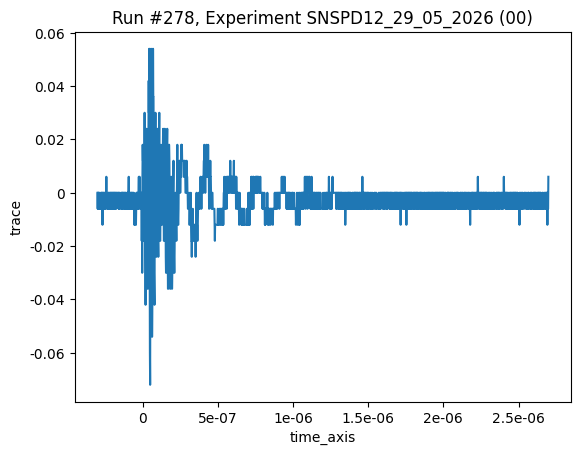

In [178]:
plot_by_id(278)

I guess this is a noise trace but I am not sure if the others were. 

In [180]:
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 279. 
279
Acquisition took 58.07 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.2750E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #279, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

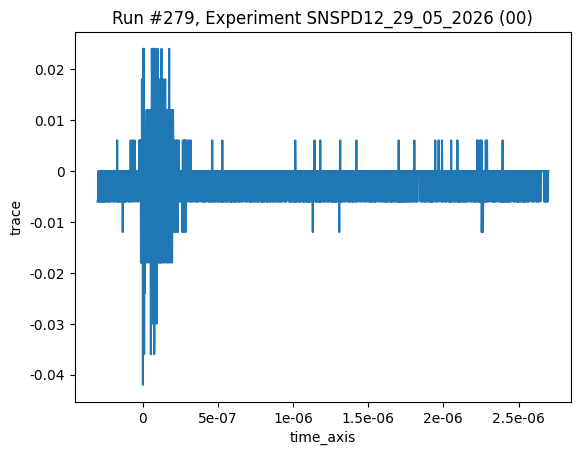

In [181]:
plot_by_id(279)

Note that using this method means that noise could be included in traces - limitation. 

In [182]:
MS.trigger_channels[0].ch1_trigger_level()

0.012

In [183]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

min_trig = 2*0.006

for i in params.device_line_2['currents'][:11]: # from 0 to -2.5uA: 
    yoko.current(i)
    params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=min_trig)

params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)
time.sleep(120)

Ramping to 0
Oscilloscope set for trace capture
update station
Starting experimental run with id: 280. 
280
Acquisition took 120.11 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 281. 
281
Acquisition took 120.10 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Starting experimental run with id: 282. 
282
Acquisition took 120.14 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace captur

Noticed that minimum step appears to be 0.006V (hence the limit on the trigger). Wondering if the vertical scaling changes this and if that impacts the search edge function.

In [184]:
float(MS.channels[0].vertical_scale())

0.15

In [188]:
MS.channels[0].vertical_scale(0.25)

In [189]:
float(MS.channels[0].vertical_scale())

0.25

In [190]:
0.25/25

0.01

In [191]:
# Run through trigger values - see what the smallest interval on the trigger is 
mult = np.arange(0, 18) 
for mult in mult: 
    trigger = 0.006*mult
    print(f'With min step 0.006V: {trigger:.3f}') # set 
    MS.trigger_channels[0].ch1_trigger_level(trigger)
    time.sleep(2)
    print(MS.trigger_channels[0].ch1_trigger_level())

With min step 0.006V: 0.000
0.0
With min step 0.006V: 0.006
0.01
With min step 0.006V: 0.012
0.01
With min step 0.006V: 0.018
0.02
With min step 0.006V: 0.024
0.02
With min step 0.006V: 0.030
0.03
With min step 0.006V: 0.036
0.04
With min step 0.006V: 0.042
0.04
With min step 0.006V: 0.048
0.05
With min step 0.006V: 0.054
0.05
With min step 0.006V: 0.060
0.06
With min step 0.006V: 0.066
0.07
With min step 0.006V: 0.072
0.07
With min step 0.006V: 0.078
0.08
With min step 0.006V: 0.084
0.08
With min step 0.006V: 0.090
0.09
With min step 0.006V: 0.096
0.1
With min step 0.006V: 0.102
0.1


It rounds to the nearest 1/25th of the vertical scale 

In [206]:
MS.channels[0].vertical_scale(0.0004)

In [207]:
float(MS.channels[0].vertical_scale())

0.0005

0.5mV seems to be the smallest vertical scale. 

In [208]:
0.0005/25

2e-05

In [210]:
# Run through trigger values - see what the smallest interval on the trigger is 
mult = np.arange(0, 18) 
for mult in mult: 
    trigger = 2e-05*mult
    print(f'Expect: {trigger}') # set 
    MS.trigger_channels[0].ch1_trigger_level(trigger)
    time.sleep(2)
    print(MS.trigger_channels[0].ch1_trigger_level())

Expect: 0.0
0.0
Expect: 2e-05
2e-05
Expect: 4e-05
4e-05
Expect: 6.000000000000001e-05
6e-05
Expect: 8e-05
8e-05
Expect: 0.0001
0.0001
Expect: 0.00012000000000000002
0.00012
Expect: 0.00014000000000000001
0.00014
Expect: 0.00016
0.00016
Expect: 0.00018
0.00018
Expect: 0.0002
0.0002
Expect: 0.00022
0.00022
Expect: 0.00024000000000000003
0.00024
Expect: 0.00026000000000000003
0.00026
Expect: 0.00028000000000000003
0.00028
Expect: 0.00030000000000000003
0.0003
Expect: 0.00032
0.00032
Expect: 0.00034
0.00034


Ok this explains a limit on the trigger, but the question of why the count depends on this is still open.

In [211]:
curr_trig = MS.trigger_channels[0].ch1_trigger_level()

In [212]:
curr_trig

0.12

In [213]:
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=curr_trig)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 291. 
291
Acquisition took 2.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;335.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [219]:
params.initialize_station()

In [223]:
v_scale_current = float(MS.channels[0].vertical_scale())
trig_current = MS.trigger_channels[0].ch1_trigger_level()
time.sleep(1)
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=trig_current, v_scale=v_scale_current)
# Count is not reading, thresholds are 60mV (threshold 1) and -240uV (threshold 2)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 293. 
293
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;315.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [222]:
MS.write('ACQUIRE:STOPAFTER RUNSTOP')
MS.write('ACQUIRE:STATE ON')

In [224]:
v_scale_current = float(MS.channels[0].vertical_scale())
trig_current = MS.trigger_channels[0].ch1_trigger_level()
time.sleep(1)
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=trig_current, v_scale=v_scale_current)
# Count is not reading, thresholds are 60mV (threshold 1) and -240uV (threshold 2)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 294. 
294
Acquisition took 2.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 128V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;875.000E-12;188;"V";20.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


Accidentally overrode count 295, counts were reading with -10uA and same thresholds as above 

In [226]:
v_scale_current = float(MS.channels[0].vertical_scale())
trig_current = MS.trigger_channels[0].ch1_trigger_level()
time.sleep(1)
params.capture_trace(MS, dmm, yoko, p_att=p_att, trigger=trig_current, v_scale=v_scale_current)
# Count is not reading, thresholds are 60mV (threshold 1) and -240uV (threshold 2). Scale is 200mV/div

Oscilloscope set for trace capture
update station
Starting experimental run with id: 296. 
296
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 51.2V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.60E-9;188;"V";8.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
